In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import Counter

In [ ]:
class ImproveAccidentCNN(nn.Module):
    def __init__(self,dropout_rate=0.2,num_classes=2):
        super().__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4),
        )

        self.fc = nn.Sequential(
            nn.Linear(256*14*14,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256,2)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

In [17]:
# -------- Training Parameters ----------
LEARNING_RATE = 1e-2
BATCH_SIZE = 32
EPOCHS = 100
WEIGHT_DECAY = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PATIENCE = 5
MIN_DELTA = 0.001
patient_cnt = 0
best_val_loss = np.inf
best_acc = 0.0              # Initialize best accuracy to 0

TRAIN = r"D:\project\dataset_cnn\train"
TEST = r"D:\project\dataset_cnn\test"

SAVE_DIR = r"D:\project\bachelor\model\weights"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "best_accident_cnn_model.pth")

PLOT_DIR = r"D:\project\bachelor\model\plot-result"
os.makedirs(PLOT_DIR, exist_ok=True)

# --------------------------------------


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = datasets.ImageFolder(TRAIN,transform=train_transform)
test_dataset = datasets.ImageFolder(TEST,transform=test_transform)

print(f"Класи: {train_dataset.classes}")

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)


model = ImproveAccidentCNN(num_classes=len(train_dataset.classes))
print(torch.cuda.is_available())

model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_loss = []
test_loss = []
train_accs = []
test_accs = []

for epoch in range(EPOCHS):

    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for images,labels in train_loader:

        images,labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()


        running_loss += loss.item()
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    train_loss.append(running_loss / len(train_loader))
    train_accs.append(correct / total)


    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images,labels in test_loader:
            images,labels = images.to(DEVICE),labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs,labels)

            val_loss += loss.item()
            _,predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()


    test_loss.append(val_loss / len(test_loader))
    test_accs.append(correct / total)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
        f"Val Loss: {test_loss[-1]:.4f} | Val Acc: {test_accs[-1]:.4f}")
    
    # Save the best model
    if test_accs[-1] > best_acc:
        best_acc = test_accs[-1]
        torch.save(model.state_dict(), r"D:\project\bachelor\model\weights\best_accident_cnn_model.pth")
        print(f"Найкраща модель збережена з точністю: {best_acc:.4f}")


    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        patient_cnt = 0
        print(f"Покращення val loss: {best_val_loss:.4f}")
    else:
        patient_cnt += 1
        print(f"Немає покращення val loss. Лічильник терпіння: {patient_cnt}/{PATIENCE}")
        if patient_cnt >= PATIENCE:
            print(f"\n Early stopping спрацював на епосі {epoch+1}")
            print(f"Найкраща val loss: {best_val_loss:.4f}")
            print(f"Найкраща val accuracy: {best_acc:.4f}")
            break    

Класи: ['1', '2']
True
Epoch 1/100 | Train Loss: 0.7220 | Train Acc: 0.5870 | Val Loss: 0.5829 | Val Acc: 0.7011
Найкраща модель збережена з точністю: 0.7011
Покращення val loss: 142.8021
Epoch 2/100 | Train Loss: 0.6277 | Train Acc: 0.6575 | Val Loss: 0.5132 | Val Acc: 0.7547
Найкраща модель збережена з точністю: 0.7547
Покращення val loss: 125.7381
Epoch 3/100 | Train Loss: 0.6011 | Train Acc: 0.6756 | Val Loss: 0.4865 | Val Acc: 0.7642
Найкраща модель збережена з точністю: 0.7642
Покращення val loss: 119.1827
Epoch 4/100 | Train Loss: 0.5641 | Train Acc: 0.7111 | Val Loss: 0.4620 | Val Acc: 0.7772
Найкраща модель збережена з точністю: 0.7772
Покращення val loss: 113.1845
Epoch 5/100 | Train Loss: 0.5553 | Train Acc: 0.7228 | Val Loss: 0.5018 | Val Acc: 0.7723
Немає покращення val loss. Лічильник терпіння: 1/5
Epoch 6/100 | Train Loss: 0.5537 | Train Acc: 0.7190 | Val Loss: 0.4631 | Val Acc: 0.7912
Найкраща модель збережена з точністю: 0.7912
Немає покращення val loss. Лічильник терп

In [18]:
model.load_state_dict(torch.load(r"D:\project\bachelor\model\weights\best_accident_cnn_model.pth"))

# Printed plots
model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu().numpy()
        pred_labels.extend(preds)
        true_labels.extend(labels.numpy())


print(classification_report(true_labels,pred_labels,target_names=train_dataset.classes))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=train_dataset.classes, 
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix")
plt.xlabel("Передбачено")
plt.ylabel("Справжнє")
plt.savefig(os.path.join(PLOT_DIR, "confusing_matrix.png"))
plt.close()


# Training Curves
plt.figure(figsize=(10,8))
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.title("Крива втрат")
plt.xlabel("Епохи")
plt.ylabel("Втрати")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "training_loss.png"))
plt.close()

plt.figure(figsize=(10,8))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.title("Крива точності")
plt.xlabel("Епохи")
plt.ylabel("Точність")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "training_acc_curv.png"))
plt.close()

print(f"\n Навчання завершено. Найкраща точність на тестовому наборі: {best_acc:.4f}")


              precision    recall  f1-score   support

           1       0.99      0.89      0.94      2000
           2       0.89      0.99      0.94      1918

    accuracy                           0.94      3918
   macro avg       0.94      0.94      0.94      3918
weighted avg       0.94      0.94      0.94      3918


 Навчання завершено. Найкраща точність на тестовому наборі: 0.9372


Початок розширеної оцінки моделі...
----------------------------------------
Global Accuracy:    0.7303
Balanced Accuracy:  0.6305 (Більш чесна метрика)
----------------------------------------

Детальний звіт по класах:
                   precision    recall  f1-score      support
0_NoAccident        0.980630  0.810000  0.887185   500.000000
1_LowDangerous      0.190476  0.333333  0.242424    24.000000
2_MediumDangerous   0.640940  0.595016  0.617124   321.000000
3_HighDangerous     0.569733  0.783673  0.659794   245.000000
accuracy            0.730275  0.730275  0.730275     0.730275
macro avg           0.595445  0.630506  0.601632  1090.000000
weighted avg        0.770837  0.730275  0.742346  1090.000000


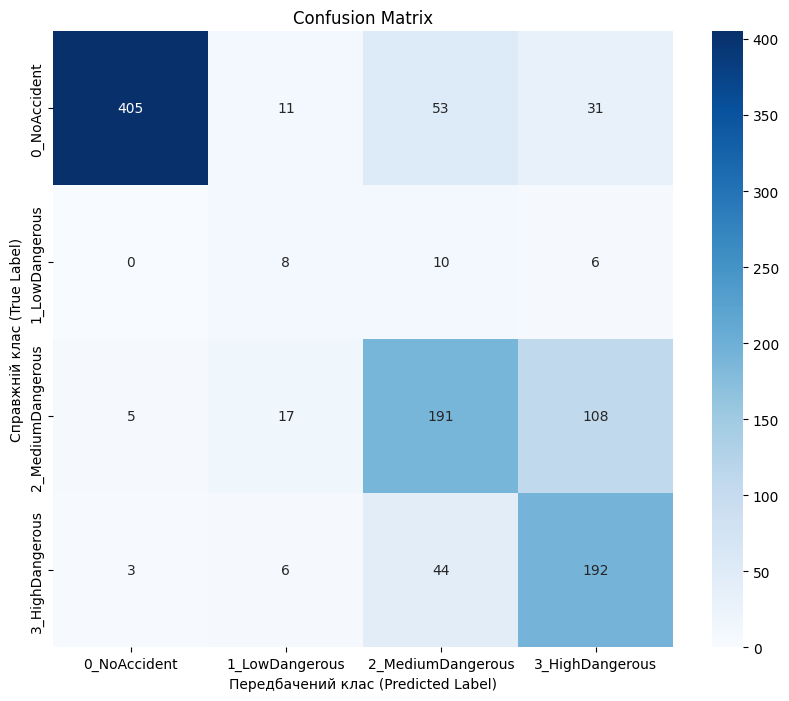


--- АНАЛІЗ БЕЗПЕКИ ---
Критичні пропуски (Була тяжка аварія, а модель сказала 'Чисто'): 3 шт.
Хибні тривоги (Було чисто, модель сказала 'Тяжка аварія'):      31 шт.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
import pandas as pd

def evaluate_model_comprehensive(model, test_loader, device, class_names, save_path=PLOT_DIR):
    model.eval()
    y_true = []
    y_pred = []
    
    print("Початок розширеної оцінки моделі...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    # 1. Загальні метрики
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    print("-" * 40)
    print(f"Global Accuracy:    {acc:.4f}")
    print(f"Balanced Accuracy:  {bal_acc:.4f} (Більш чесна метрика)")
    print("-" * 40)
    
    # 2. Детальний звіт (Precision, Recall, F1)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nДетальний звіт по класах:")
    print(report_df)
    
    # Збереження звіту в CSV
    report_df.to_csv(f"{save_path}/metrics_report.csv")
    
    # 3. Матриця плутанини (Графік)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.ylabel('Справжній клас (True Label)')
    plt.xlabel('Передбачений клас (Predicted Label)')
    plt.title('Confusion Matrix')
    plt.savefig(f"{save_path}/confusion_matrix_final.png")
    plt.show()
    plt.close()
    

evaluate_model_comprehensive(model, test_loader, DEVICE, train_dataset.classes)


In [3]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
)


class AccidentClassifier:
    """
    ResNet50-based класифікатор ДТП / не ДТП.

    Приклад інтеграції в систему:
    ─────────────────────────────
    clf = AccidentClassifier.load('best_accident_classifier.pth')

    # Зображення з диску:
    label, probs = clf.predict('/path/to/frame.jpg')

    # Кадр з відео (np.ndarray BGR від OpenCV):
    label, probs = clf.predict(cv2_frame)

    # Отримати впевненість:
    is_accident = label == 'Accident'
    confidence  = probs[clf.class_names.index('Accident')]
    """

    # ── ImageNet нормалізація ──────────────────────────────────────────
    _MEAN = [0.485, 0.456, 0.406]
    _STD  = [0.229, 0.224, 0.225]

    _INFERENCE_TRANSFORM = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(_MEAN, _STD),
    ])

    # ──────────────────────────────────────────────────────────────────
    def __init__(self, model: nn.Module, class_names: list,
                 device: str = 'cpu'):
        self.model       = model
        self.class_names = class_names
        self.device      = device
        self.model.to(device)

    # ── Конструктори ──────────────────────────────────────────────────
    @classmethod
    def build(cls, class_names: list,
              dropout: float = 0.4,
              device: str = 'cpu') -> 'AccidentClassifier':
        """
        Створює модель з pretrained ImageNet вагами.
        Всі шари одразу розморожені для повного навчання.
        """
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Розморожуємо ВСІ шари — навчання без фаз
        for param in backbone.parameters():
            param.requires_grad = True

        # Замінюємо FC-голову
        in_features = backbone.fc.in_features  # 2048
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(128, len(class_names)),
        )

        total     = sum(p.numel() for p in backbone.parameters())
        trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
        # print(f'Параметрів: {total:,}  (trainable: {trainable:,})')

        return cls(backbone, class_names, device)

    @classmethod
    def load(cls, path: str,
             device: str = None) -> 'AccidentClassifier':
        """
        Завантажує збережену модель з .pth файлу.
        Використовується для інтеграції в систему.

        clf = AccidentClassifier.load('best.pth')
        """
        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'

        checkpoint   = torch.load(path, map_location=device)
        class_names  = checkpoint['class_names']
        dropout      = checkpoint.get('dropout', 0.4)

        # Будуємо архітектуру (без завантаження ImageNet ваг)
        backbone = models.resnet50(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(128, len(class_names)),
        )
        backbone.load_state_dict(checkpoint['model_state_dict'])

        obj = cls(backbone, class_names, device)
        obj.model.eval()
        # print(f'✅ Модель завантажена: {path}')
        # print(f'   Класи  : {class_names}')
        # print(f'   Device : {device}')
        # if 'best_val_acc' in checkpoint:
        #     print(f'   Val Acc: {checkpoint["best_val_acc"]:.4f}')
        return obj

    # ── Збереження ────────────────────────────────────────────────────
    def save(self, path: str, best_val_acc: float = 0.0,
             dropout: float = 0.4):
        """
        Зберігає ваги + метадані (class_names, dropout, val_acc).
        """
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'class_names'     : self.class_names,
            'dropout'         : dropout,
            'best_val_acc'    : best_val_acc,
        }, path)

    # ── Навчання ──────────────────────────────────────────────────────
    def fit(
        self,
        train_loader: DataLoader,
        val_loader:   DataLoader,
        epochs:       int   = 50,
        lr:           float = 1e-4,
        weight_decay: float = 1e-4,
        patience:     int   = 8,
        min_delta:    float = 0.001,
        save_path:    str   = None,
        plot_dir:     str   = None,
        class_weights: torch.Tensor = None,
    ) -> dict:
        """
        Єдина фаза навчання — всі шари відразу.

        Повертає словник з історією:
          {'train_loss': [...], 'val_loss': [...],
           'train_acc':  [...], 'val_acc':  [...]}
        """
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # Диференційовані LR: backbone з меншим, голова — з повним
        fc_params       = list(self.model.fc.parameters())
        fc_ids          = {id(p) for p in fc_params}
        backbone_params = [p for p in self.model.parameters()
                           if id(p) not in fc_ids]

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': lr * 0.1},   # backbone × 0.1
            {'params': fc_params,       'lr': lr},          # FC голова
        ], weight_decay=weight_decay)

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=1e-6
        )

        history = {'train_loss': [], 'val_loss': [],
                   'train_acc' : [], 'val_acc' : []}

        best_val_loss = float('inf')
        best_val_acc  = 0.0
        patience_cnt  = 0

        print(f"\n{'='*65}")
        print(f"  Навчання ResNet50 — {epochs} епох | device={self.device}")
        print(f"  LR backbone={lr*0.1:.2e}  LR head={lr:.2e}")
        print(f"{'='*65}")

        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = self._run_epoch(train_loader, criterion, optimizer)
            vl_loss, vl_acc = self._run_epoch(val_loader,   criterion)
            scheduler.step()

            history['train_loss'].append(tr_loss)
            history['val_loss'].append(vl_loss)
            history['train_acc'].append(tr_acc)
            history['val_acc'].append(vl_acc)

            saved = ''
            if vl_acc > best_val_acc:
                best_val_acc = vl_acc
                if save_path:
                    self.save(save_path, best_val_acc)
                saved = '  ✅'

            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'Train {tr_loss:.4f}/{tr_acc:.4f} | '
                  f'Val {vl_loss:.4f}/{vl_acc:.4f}{saved}')

            # Early stopping
            if vl_loss < best_val_loss - min_delta:
                best_val_loss = vl_loss
                patience_cnt  = 0
            else:
                patience_cnt += 1
                if patience_cnt >= patience:
                    print(f'\n⛔ Early stopping — епоха {epoch}')
                    break

        print(f'\n🏆 Найкраща Val Acc: {best_val_acc:.4f}')

        if plot_dir:
            self._plot_history(history, plot_dir)

        return history

    # ── Оцінка ────────────────────────────────────────────────────────
    def evaluate(
        self,
        loader:    DataLoader,
        weights_path: str = None,
        plot_dir:  str   = None,
    ) -> dict:
        """
        Повна оцінка: accuracy, balanced_accuracy, classification_report,
        confusion matrix, аналіз критичних помилок.

        Якщо weights_path вказано — завантажує найкращі ваги перед оцінкою.
        """
        if weights_path:
            ckpt = torch.load(weights_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state_dict'])
            print(f'Завантажено ваги: {weights_path}')

        self.model.eval()
        y_true, y_pred, y_prob = [], [], []

        with torch.no_grad():
            for images, labels in loader:
                outputs = self.model(images.to(self.device))
                probs   = torch.softmax(outputs, dim=1)
                preds   = outputs.argmax(dim=1)
                y_true.extend(labels.numpy())
                y_pred.extend(preds.cpu().numpy())
                y_prob.extend(probs.cpu().numpy())

        acc     = accuracy_score(y_true, y_pred)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        print(f"\n{'='*50}")
        print(f'  Accuracy          : {acc:.4f}')
        print(f'  Balanced Accuracy : {bal_acc:.4f}')
        print(f"{'='*50}")

        report = classification_report(
            y_true, y_pred, target_names=self.class_names, output_dict=True
        )
        report_df = pd.DataFrame(report).transpose()
        print(report_df.to_string())

        if plot_dir:
            report_df.to_csv(os.path.join(plot_dir, 'metrics_report.csv'))
            self._plot_confusion_matrix(y_true, y_pred, plot_dir)

        # Критичні помилки
        y_true_arr = np.array(y_true)
        y_pred_arr = np.array(y_pred)
        acc_idx    = 0  # Accident — завжди перший клас

        fn = int(np.sum((y_true_arr == acc_idx) & (y_pred_arr != acc_idx)))
        fp = int(np.sum((y_true_arr != acc_idx) & (y_pred_arr == acc_idx)))
        print(f'\n--- АНАЛІЗ БЕЗПЕКИ ---')
        print(f'❗ Критичні пропуски (ДТП → Чисто) : {fn}')
        print(f'⚠️  Хибні тривоги   (Чисто → ДТП) : {fp}')

        return {
            'accuracy': acc, 'balanced_accuracy': bal_acc,
            'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
            'false_negatives': fn, 'false_positives': fp,
        }

    # ── Інференс ──────────────────────────────────────────────────────
    def predict(
        self,
        source,                     # str | Path | PIL.Image | np.ndarray
        threshold: float = 0.5,     # поріг для класу accident (index=0)
    ) -> tuple:
        """
        Передбачення для одного зображення.

        source може бути:
          - str або Path  → шлях до файлу
          - PIL.Image
          - np.ndarray    → BGR кадр від OpenCV

        Повертає:
          (label: str, probs: np.ndarray)

        Приклад:
          label, probs = clf.predict(cv2_frame)
          is_accident  = label == 'Accident'
          confidence   = probs[0]  # якщо Accident — перший клас
        """
        img = self._load_image(source)
        inp = self._INFERENCE_TRANSFORM(img).unsqueeze(0).to(self.device)

        self.model.eval()
        with torch.no_grad():
            probs = torch.softmax(self.model(inp), dim=1)[0].cpu().numpy()

        # Якщо є клас Accident — використовуємо поріг
        acc_names = [n for n in self.class_names
                     if 'accident' in n.lower() and 'non' not in n.lower()]
        if acc_names:
            acc_idx      = self.class_names.index(acc_names[0])
            label = acc_names[0] if probs[acc_idx] >= threshold \
                    else self.class_names[1 - acc_idx]
        else:
            label = self.class_names[int(np.argmax(probs))]

        return label, probs

    def predict_batch(
        self,
        sources: list,
        threshold: float = 0.5,
    ) -> list:
        """
        Батч інференс.
        sources: список str/Path/PIL/np.ndarray
        Повертає: [(label, probs), ...]
        """
        imgs = [self._INFERENCE_TRANSFORM(self._load_image(s))
                for s in sources]
        batch = torch.stack(imgs).to(self.device)

        self.model.eval()
        with torch.no_grad():
            all_probs = torch.softmax(self.model(batch), dim=1).cpu().numpy()

        results = []
        for probs in all_probs:
            label = self.class_names[int(np.argmax(probs))]
            results.append((label, probs))
        return results

    # ── Grad-CAM ──────────────────────────────────────────────────────
    def gradcam(
        self,
        source,
        class_idx: int = None,
    ) -> np.ndarray:
        """
        Генерує Grad-CAM теплову карту для зображення.
        Повертає overlay (H×W×3 float32 в [0,1]).
        """
        img     = self._load_image(source)
        img_np  = np.array(img.resize((224, 224))) / 255.0
        inp     = self._INFERENCE_TRANSFORM(img).unsqueeze(0).to(self.device)

        gradients  = []
        activations = []

        def fwd_hook(_, __, out): activations.append(out.detach())
        def bwd_hook(_, __, g):   gradients.append(g[0].detach())

        handle_f = self.model.layer4[-1].register_forward_hook(fwd_hook)
        handle_b = self.model.layer4[-1].register_full_backward_hook(bwd_hook)

        self.model.eval()
        output = self.model(inp)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        handle_f.remove(); handle_b.remove()

        weights = gradients[0].mean(dim=(2, 3), keepdim=True)
        cam     = torch.relu((weights * activations[0]).sum(dim=1)).squeeze()
        cam     = cam.cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        heatmap = cv2.resize(cam, (224, 224))
        overlay = 0.5 * img_np + 0.5 * plt.cm.jet(heatmap)[..., :3]
        return np.clip(overlay, 0, 1)

    # ── Приватні методи ───────────────────────────────────────────────
    def _run_epoch(
        self,
        loader:    DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer = None,
    ) -> tuple:
        is_train = optimizer is not None
        self.model.train() if is_train else self.model.eval()

        total_loss, correct, total = 0.0, 0, 0
        ctx = torch.enable_grad() if is_train else torch.no_grad()

        with ctx:
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss    = criterion(outputs, labels)

                if is_train:
                    optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()

                total_loss += loss.item()
                correct    += outputs.argmax(1).eq(labels).sum().item()
                total      += labels.size(0)

        return total_loss / len(loader), correct / total

    def _load_image(self, source) -> Image.Image:
        """Уніфіковане завантаження: str/Path/PIL/np.ndarray → PIL RGB."""
        if isinstance(source, (str, Path)):
            return Image.open(source).convert('RGB')
        if isinstance(source, np.ndarray):
            # OpenCV BGR → RGB
            return Image.fromarray(cv2.cvtColor(source, cv2.COLOR_BGR2RGB))
        if isinstance(source, Image.Image):
            return source.convert('RGB')
        raise TypeError(f'Непідтримуваний тип: {type(source)}')

    def _plot_history(self, history: dict, save_dir: str):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, metric, title in zip(
            axes,
            [('train_loss','val_loss'), ('train_acc','val_acc')],
            ['Loss', 'Accuracy']
        ):
            ax.plot(history[metric[0]], label='Train')
            ax.plot(history[metric[1]], label='Val')
            ax.set_title(title); ax.legend(); ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=150)
        plt.show(); plt.close()

    def _plot_confusion_matrix(self, y_true, y_pred, save_dir: str):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names,
                    yticklabels=self.class_names)
        plt.title('Confusion Matrix'); plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=150)
        plt.show(); plt.close()



Accident
[0.8664214  0.13357857]


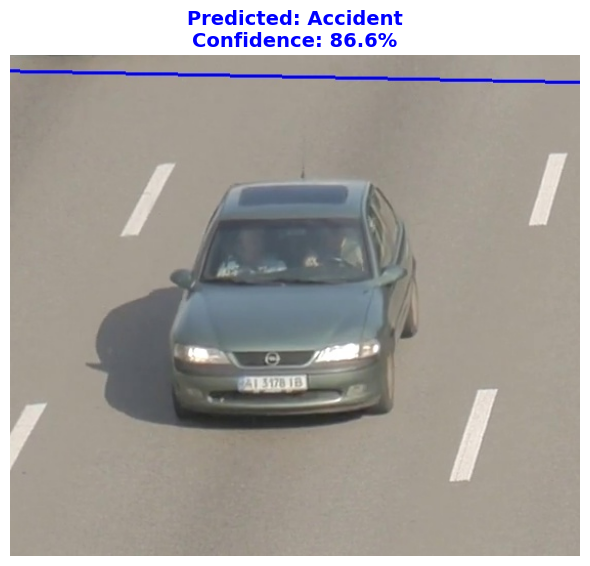

In [19]:
chosen_image_path = r'E:\personalproject\bachelor\logs\logs_traffic_video_v1\resnet_crops\f000090_id275_SCORE_0.823.jpg'
clf = AccidentClassifier.load(r"E:\personalproject\bachelor\model\weights\resnet50_accident.pth",device='cpu')
# ── 2. Отримуємо передбачення моделі ───────────────────────────────────
label, probs = clf.predict(chosen_image_path)
confidence = max(probs)
print(label)
print(probs)

# ── 3. Візуалізація ────────────────────────────────────────────────────
# Завантажуємо оригінальне зображення через PIL для гарного відображення
img = Image.open(chosen_image_path).convert('RGB')

plt.figure(figsize=(6, 6))
plt.imshow(img)

# Виводимо результат передбачення у заголовок
plt.title(
    f'Predicted: {label}\nConfidence: {confidence:.1%}', 
    fontsize=14, 
    fontweight='bold',
    color='blue' # Можна змінити колір за бажанням
)

plt.axis('off')
plt.tight_layout()
# plt.savefig('my_single_prediction.png', dpi=150) # Розкоментуй, якщо треба зберегти
plt.show()
plt.close()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Відтворення архітектури моделі
# ---------------------------------------------------------
device = torch.device("cpu") # або "cuda"

# Створюємо базову модель (без попередньо навчених ваг ImageNet, бо завантажимо свої)
model = models.resnet50(weights=None) 
num_ftrs = model.fc.in_features
# Замінюємо останній шар так само, як це робилося під час навчання
model.fc = nn.Linear(num_ftrs, 2) 

# ---------------------------------------------------------
# 2. Завантаження ваших навчених ваг
# ---------------------------------------------------------
path = r"E:\personalproject\bachelor\model\weights\resnet50_accident.pth"

# Завантажуємо файл
checkpoint = torch.load(path, map_location=device)

# Залежно від того, як ви зберігали файл, це може бути просто словник ваг 
# або словник із ключем (наприклад, 'model_state'). Зазвичай достатньо цього:
try:
    model.load_state_dict(checkpoint)
except RuntimeError:
    # Якщо ви зберігали модель цілком через torch.save(model, ...), 
    # тоді просто: model = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])

model = model.to(device)
model.eval() # Обов'язково! Вимикає Dropout та фіксує BatchNorm для інференсу

# ---------------------------------------------------------
# 3. Підготовка зображення (Transforms)
# ---------------------------------------------------------
# ResNet очікує зображення 224x224 та специфічну нормалізацію
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

chosen_image_path = r'E:\personalproject\bachelor\logs\logs_traffic_video_v1\resnet_crops\f000090_id275_SCORE_0.823.jpg'
img = Image.open(chosen_image_path).convert('RGB')

# Перетворюємо зображення у тензор та додаємо вимір батчу: [1, 3, 224, 224]
input_tensor = transform(img).unsqueeze(0).to(device)

# ---------------------------------------------------------
# 4. Передбачення (Inference)
# ---------------------------------------------------------
with torch.no_grad(): # Вимикаємо розрахунок градієнтів для швидкості
    outputs = model(input_tensor)
    # Перетворюємо сирі логіти у ймовірності від 0 до 1
    probs = torch.softmax(outputs, dim=1).squeeze().cpu().numpy()

# Визначаємо класи (порядок має збігатися з тим, як ви навчали)
class_names = ['Non-Accident', 'Accident'] 
predicted_idx = probs.argmax()

label = class_names[predicted_idx]
confidence = probs[predicted_idx]

# ---------------------------------------------------------
# 5. Візуалізація
# ---------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.imshow(img)

plt.title(
    f'Predicted: {label}\nConfidence: {confidence:.1%}', 
    fontsize=14, 
    fontweight='bold',
    color='blue'
)

plt.axis('off')
plt.tight_layout()
plt.show()
plt.close()

KeyError: 'model_state'